# 2:1 FMR Wave-Error Convergence

This experiment evolves the Gaussian-windowed $E_y/B_z$ wave from `fmr_high_frequency_wave_crossing.ipynb` on two geometrically identical, single-level 2:1 FMR meshes. The second run halves both the root and fine spacings.

At every synchronized snapshot, the continuum right-moving solution is subtracted at the native Yee $E_y$ locations. The composite $L_2$ error uses root data outside the refined volume and fine data inside it, so covered root cells are not counted twice. The observed order is

$$p(t)=\log_2\left(\frac{\lVert e_h(t)\rVert_2}{\lVert e_{h/2}(t)\rVert_2}\right).$$

The notebook reports the measured behavior without imposing an expected order: interface reflection is part of the numerical result.

In [2]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
from tempfile import TemporaryDirectory

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Image, Markdown, display
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle


def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "PyPIC3D").is_dir() and (candidate / "test_notebooks").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the PyPIC3D FMR_DEV checkout.")


REPO_ROOT = find_repo_root()

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from PyPIC3D.initialization import initialize_simulation
from PyPIC3D.fmr import (
    B_FIELD_LOCATIONS,
    E_FIELD_LOCATIONS,
    prolong_e_to_fine_interface,
)

jax.config.update("jax_enable_x64", True)
mpl.rcParams["animation.embed_limit"] = 100.0

print(f"Repository: {REPO_ROOT}")
print(f"JAX devices: {jax.devices()}")

Repository: /home/christopherwoolford/Documents/Research/projects/PyPIC3D/scratch/FMR_DEV
JAX devices: [CpuDevice(id=0)]


## Fixed physical problem and resolution pair

The physical box, FMR patch, wave, final time, and frame times are identical in both runs. `resolution_scale=2` doubles every root-grid count and both bounds of the patch in index space; the 2:1 refinement ratio is unchanged. Thus the root/fine spacings change from $1/0.5$ to $0.5/0.25$, while the finest-grid Courant number remains fixed.

In [3]:
RESOLUTION_SCALES = (1, 2)
REFINEMENT_RATIO = 2
BASE_ROOT_SHAPE = np.asarray((128, 6, 6), dtype=int)
BASE_PATCH_START = np.asarray((32, 1, 1), dtype=int)
BASE_PATCH_STOP = np.asarray((80, 5, 5), dtype=int)
GUARD_CELLS = 2

DOMAIN_MIN = np.asarray((0.0, 0.0, 0.0))
DOMAIN_MAX = np.asarray((128.0, 6.0, 6.0))
PATCH_MIN = np.asarray((32.0, 1.0, 1.0))
PATCH_MAX = np.asarray((80.0, 5.0, 5.0))

WAVE_AMPLITUDE = 1.0
PULSE_CENTER = 56.0
PULSE_WIDTH = 6.0
WAVELENGTH = 16.0
WAVE_NUMBER = 2.0 * np.pi / WAVELENGTH

BASE_DT = 0.15
FINAL_TIME = 54.0
FRAME_DT = 0.6
FRAME_TIMES = np.linspace(0.0, FINAL_TIME, int(round(FINAL_TIME / FRAME_DT)) + 1)
NUM_FRAMES = len(FRAME_TIMES)
PLOT_Z = 3.0
ROUND_OFF_THRESHOLD = 100.0 * np.finfo(float).eps * WAVE_AMPLITUDE

assert NUM_FRAMES == 91
assert np.isclose(FRAME_TIMES[-1], FINAL_TIME)
assert np.max(np.abs(np.exp(-0.5 * ((np.asarray((32.0, 80.0)) - PULSE_CENTER) / PULSE_WIDTH) ** 2))) < 5.0e-4

## Production setup and native Yee initialization

Each run is created by `initialize_simulation` and advanced by `time_loop_electrodynamic_fmr_fields`. The same analytic profile is sampled independently on the native root and fine $E_y/B_z$ locations. The production prolongation operator then supplies the constrained fine-$E$ interface values.

In [4]:
def fmr_config(resolution_scale, output_dir):
    root_shape = tuple(int(value) for value in resolution_scale * BASE_ROOT_SHAPE)
    patch_start = tuple(int(value) for value in resolution_scale * BASE_PATCH_START)
    patch_stop = tuple(int(value) for value in resolution_scale * BASE_PATCH_STOP)
    dt = BASE_DT / resolution_scale

    return {
        "static_parameters": {
            "name": f"2:1 FMR wave convergence, scale={resolution_scale}",
            "output_dir": str(output_dir),
            "solver": "electrodynamic_yee",
            "Nt": int(round(FINAL_TIME / dt)),
            "guard_cells": GUARD_CELLS,
            "particle_tile_nx": root_shape[0],
            "particle_tile_ny": root_shape[1],
            "particle_tile_nz": root_shape[2],
            "current_calculation": "j_from_rhov",
            "filter_j": "none",
            "x_bc": "periodic",
            "y_bc": "periodic",
            "z_bc": "periodic",
        },
        "dynamic_parameters": {
            "Nx": root_shape[0],
            "Ny": root_shape[1],
            "Nz": root_shape[2],
            "x_min": DOMAIN_MIN[0],
            "x_max": DOMAIN_MAX[0],
            "y_min": DOMAIN_MIN[1],
            "y_max": DOMAIN_MAX[1],
            "z_min": DOMAIN_MIN[2],
            "z_max": DOMAIN_MAX[2],
            "dt": dt,
            "C": 1.0,
            "eps": 1.0,
            "mu": 1.0,
        },
        "fmr": {
            "enabled": True,
            "levels": [{
                "parent": 0,
                "refinement_ratio": REFINEMENT_RATIO,
                "coarse_start": list(patch_start),
                "coarse_stop": list(patch_stop),
            }],
        },
    }


def component_axis(grids, locations, axis):
    tiled_grid = grids.tiled_vertex_grid if locations[axis] == "V" else grids.tiled_center_grid
    return tiled_grid[axis][0, 0, 0]


def active_component_axis(level, level_data, locations, axis, guard_cells):
    cells = (level.Nx, level.Ny, level.Nz)[axis]
    axis_values = component_axis(level_data.grids, locations, axis)
    return axis_values[guard_cells:guard_cells + cells]


def wave_profile(x, time=0.0):
    displacement = x - (PULSE_CENTER + time)
    envelope = jnp.exp(-0.5 * (displacement / PULSE_WIDTH) ** 2)
    return WAVE_AMPLITUDE * envelope * jnp.cos(WAVE_NUMBER * displacement)


def initialize_wave(fields, dynamic_parameters):
    E_levels, B_levels, J_levels = fields[:3]
    initialized_E = []
    initialized_B = []

    for E_level, B_level, level_data in zip(E_levels, B_levels, dynamic_parameters.fmr.levels):
        x_Ey = component_axis(level_data.grids, E_FIELD_LOCATIONS[1], axis=0)
        x_Bz = component_axis(level_data.grids, B_FIELD_LOCATIONS[2], axis=0)

        Ex, Ey, Ez = E_level
        Bx, By, Bz = B_level
        Ey = jnp.broadcast_to(
            wave_profile(x_Ey)[jnp.newaxis, jnp.newaxis, jnp.newaxis, :, jnp.newaxis, jnp.newaxis],
            Ey.shape,
        )
        Bz = jnp.broadcast_to(
            wave_profile(x_Bz)[jnp.newaxis, jnp.newaxis, jnp.newaxis, :, jnp.newaxis, jnp.newaxis],
            Bz.shape,
        )
        initialized_E.append((Ex, Ey, Ez))
        initialized_B.append((Bx, By, Bz))

    E_levels = tuple(initialized_E)
    B_levels = tuple(initialized_B)
    E_levels = (
        E_levels[0],
        prolong_e_to_fine_interface(
            E_levels[0],
            E_levels[1],
            dynamic_parameters.fmr.levels[1].e_interface_maps,
        ),
    )
    return (E_levels, B_levels, J_levels, *fields[3:])

## JIT-compiled evolution and analytical subtraction

The JAX scan retains the active three-dimensional $E_y$ arrays at all 91 frame times. Analytical subtraction is performed afterward at the matching root and fine Yee coordinates. The weighted norm uses the physical sample volume on each level.

In [5]:
def analytic_history(x):
    displacement = x[np.newaxis, :, np.newaxis, np.newaxis] - (
        PULSE_CENTER + FRAME_TIMES[:, np.newaxis, np.newaxis, np.newaxis]
    )
    return WAVE_AMPLITUDE * np.exp(-0.5 * (displacement / PULSE_WIDTH) ** 2) * np.cos(
        WAVE_NUMBER * displacement
    )


def composite_l2_history(root_error, fine_error, root_axes, fine_spacing):
    root_x, root_y, root_z = root_axes
    root_inside_patch = (
        (root_x[:, None, None] >= PATCH_MIN[0])
        & (root_x[:, None, None] < PATCH_MAX[0])
        & (root_y[None, :, None] >= PATCH_MIN[1])
        & (root_y[None, :, None] < PATCH_MAX[1])
        & (root_z[None, None, :] >= PATCH_MIN[2])
        & (root_z[None, None, :] < PATCH_MAX[2])
    )
    root_active = ~root_inside_patch
    root_spacing = np.asarray((root_x[1] - root_x[0], root_y[1] - root_y[0], root_z[1] - root_z[0]))
    root_volume = float(np.prod(root_spacing))
    fine_volume = float(np.prod(fine_spacing))

    squared_error_integral = (
        root_volume * np.sum(root_error[:, root_active] ** 2, axis=1)
        + fine_volume * np.sum(fine_error.reshape(NUM_FRAMES, -1) ** 2, axis=1)
    )
    composite_volume = root_volume * np.count_nonzero(root_active) + fine_volume * fine_error[0].size
    return np.sqrt(squared_error_integral / composite_volume)


def run_resolution(resolution_scale):
    with TemporaryDirectory(prefix=f"pypic3d_fmr_convergence_s{resolution_scale}_") as output_dir:
        (
            evolve_loop,
            particles,
            fields,
            static_parameters,
            dynamic_parameters,
            _plotting_parameters,
            _plasma_parameters,
            species_config,
        ) = initialize_simulation(fmr_config(resolution_scale, output_dir))
        assert evolve_loop.__name__ == "time_loop_electrodynamic_fmr_fields"

        fields = initialize_wave(fields, dynamic_parameters)
        steps_per_frame = int(round(FRAME_DT / float(dynamic_parameters.dt)))
        assert np.isclose(steps_per_frame * float(dynamic_parameters.dt), FRAME_DT)

        root_level, fine_level = static_parameters.fmr_levels
        root_data, fine_data = dynamic_parameters.fmr.levels
        g = int(static_parameters.guard_cells)
        active_root = (
            slice(g, g + root_level.Nx),
            slice(g, g + root_level.Ny),
            slice(g, g + root_level.Nz),
        )
        active_fine = (
            slice(g, g + fine_level.Nx),
            slice(g, g + fine_level.Ny),
            slice(g, g + fine_level.Nz),
        )

        root_axes = tuple(
            active_component_axis(root_level, root_data, E_FIELD_LOCATIONS[1], axis, g)
            for axis in range(3)
        )
        fine_axes = tuple(
            active_component_axis(fine_level, fine_data, E_FIELD_LOCATIONS[1], axis, g)
            for axis in range(3)
        )

        def sample_Ey(field_state):
            E_levels = field_state[0]
            return (
                E_levels[0][1][0, 0, 0][active_root],
                E_levels[1][1][0, 0, 0][active_fine],
            )

        initial_Ey = sample_Ey(fields)

        def advance_one_step(field_state):
            _, field_state = evolve_loop(
                particles,
                species_config,
                field_state,
                static_parameters,
                dynamic_parameters,
            )
            return field_state

        def advance_one_frame(field_state, _):
            field_state = jax.lax.fori_loop(
                0,
                steps_per_frame,
                lambda _step, state: advance_one_step(state),
                field_state,
            )
            return field_state, sample_Ey(field_state)

        @jax.jit
        def evolve_and_sample(field_state):
            return jax.lax.scan(
                advance_one_frame,
                field_state,
                xs=None,
                length=NUM_FRAMES - 1,
            )

        _final_fields, histories = evolve_and_sample(fields)
        histories = tuple(
            jnp.concatenate((initial[jnp.newaxis], history), axis=0)
            for initial, history in zip(initial_Ey, histories)
        )
        histories[1].block_until_ready()

        root_Ey, fine_Ey = (np.asarray(jax.device_get(history)) for history in histories)
        root_axes = tuple(np.asarray(jax.device_get(axis)) for axis in root_axes)
        fine_axes = tuple(np.asarray(jax.device_get(axis)) for axis in fine_axes)
        root_error = root_Ey - analytic_history(root_axes[0])
        fine_error = fine_Ey - analytic_history(fine_axes[0])
        fine_spacing = np.asarray(fine_level.spacing, dtype=float)
        l2_error = composite_l2_history(root_error, fine_error, root_axes, fine_spacing)

        return {
            "resolution_scale": resolution_scale,
            "refinement_ratio": int(fine_level.refinement_ratio),
            "root_shape": (root_level.Nx, root_level.Ny, root_level.Nz),
            "fine_shape": (fine_level.Nx, fine_level.Ny, fine_level.Nz),
            "root_spacing": np.asarray(root_level.spacing, dtype=float),
            "fine_spacing": fine_spacing,
            "root_bounds": np.asarray((root_level.x_min, root_level.x_max, root_level.y_min, root_level.y_max, root_level.z_min, root_level.z_max)),
            "fine_bounds": np.asarray((fine_level.x_min, fine_level.x_max, fine_level.y_min, fine_level.y_max, fine_level.z_min, fine_level.z_max)),
            "dt": float(dynamic_parameters.dt),
            "times": FRAME_TIMES.copy(),
            "root_axes": root_axes,
            "fine_axes": fine_axes,
            "root_error": root_error,
            "fine_error": fine_error,
            "l2_error": l2_error,
        }

## Run both resolutions

The two static array layouts compile separately. The assertions below verify that this is a fixed-physics resolution doubling rather than a refinement-ratio sweep.

In [6]:
results = {}
for resolution_scale in RESOLUTION_SCALES:
    print(f"Running resolution scale {resolution_scale}...")
    results[resolution_scale] = run_resolution(resolution_scale)

coarse = results[1]
fine = results[2]

assert coarse["refinement_ratio"] == fine["refinement_ratio"] == 2
assert fine["root_shape"] == tuple(2 * np.asarray(coarse["root_shape"]))
assert fine["fine_shape"] == tuple(2 * np.asarray(coarse["fine_shape"]))
assert np.allclose(fine["root_spacing"], 0.5 * coarse["root_spacing"])
assert np.allclose(fine["fine_spacing"], 0.5 * coarse["fine_spacing"])
assert np.isclose(fine["dt"], 0.5 * coarse["dt"])
assert np.array_equal(coarse["times"], fine["times"])
assert np.allclose(coarse["root_bounds"], fine["root_bounds"])
assert np.allclose(coarse["fine_bounds"], fine["fine_bounds"])
assert np.allclose(coarse["root_bounds"], (0.0, 128.0, 0.0, 6.0, 0.0, 6.0))
assert np.allclose(coarse["fine_bounds"], (32.0, 80.0, 1.0, 5.0, 1.0, 5.0))

for result in results.values():
    assert result["root_error"].shape[0] == NUM_FRAMES
    assert result["fine_error"].shape[0] == NUM_FRAMES
    assert np.isfinite(result["root_error"]).all()
    assert np.isfinite(result["fine_error"]).all()
    assert np.isfinite(result["l2_error"]).all()

print("Validated one 2:1 FMR level, fixed physical geometry, and exact resolution doubling.")

Running resolution scale 1...
Initializing Simulation: 2:1 FMR wave convergence, scale=1

Using boundary conditions: x: periodic, y: periodic, z: periodic

Using user defined dt: 0.15
Adjusting t_wind to 54.0 based on provided dt and Nt

time window: 54.0 s with 360 time steps of 0.15 s
x window: 128.0 m [0.0, 128.0] with dx: 1.0 m
y window: 6.0 m [-1.1102230246251565e-16, 6.0] with dy: 1.0 m
z window: 6.0 m [-1.1102230246251565e-16, 6.0] with dz: 1.0 m

Skipping single-resolution energy diagnostics for field-only FMR

Relativistic simulation
Using boris particle pusher
Using field-only electrodynamic Yee FMR solver
Using J from rhov current calculation method with filter: none
Using tiled Yee storage with tile shape: (128, 6, 6)
Running resolution scale 2...
Initializing Simulation: 2:1 FMR wave convergence, scale=2

Using boundary conditions: x: periodic, y: periodic, z: periodic

Using user defined dt: 0.075
Adjusting t_wind to 54.0 based on provided dt and Nt

time window: 54.0 s w

## Composite error and log2 convergence order

Frames for which either norm is at the roundoff threshold are left undefined. No target order is asserted because the purpose of this notebook is to expose the measured interface behavior.

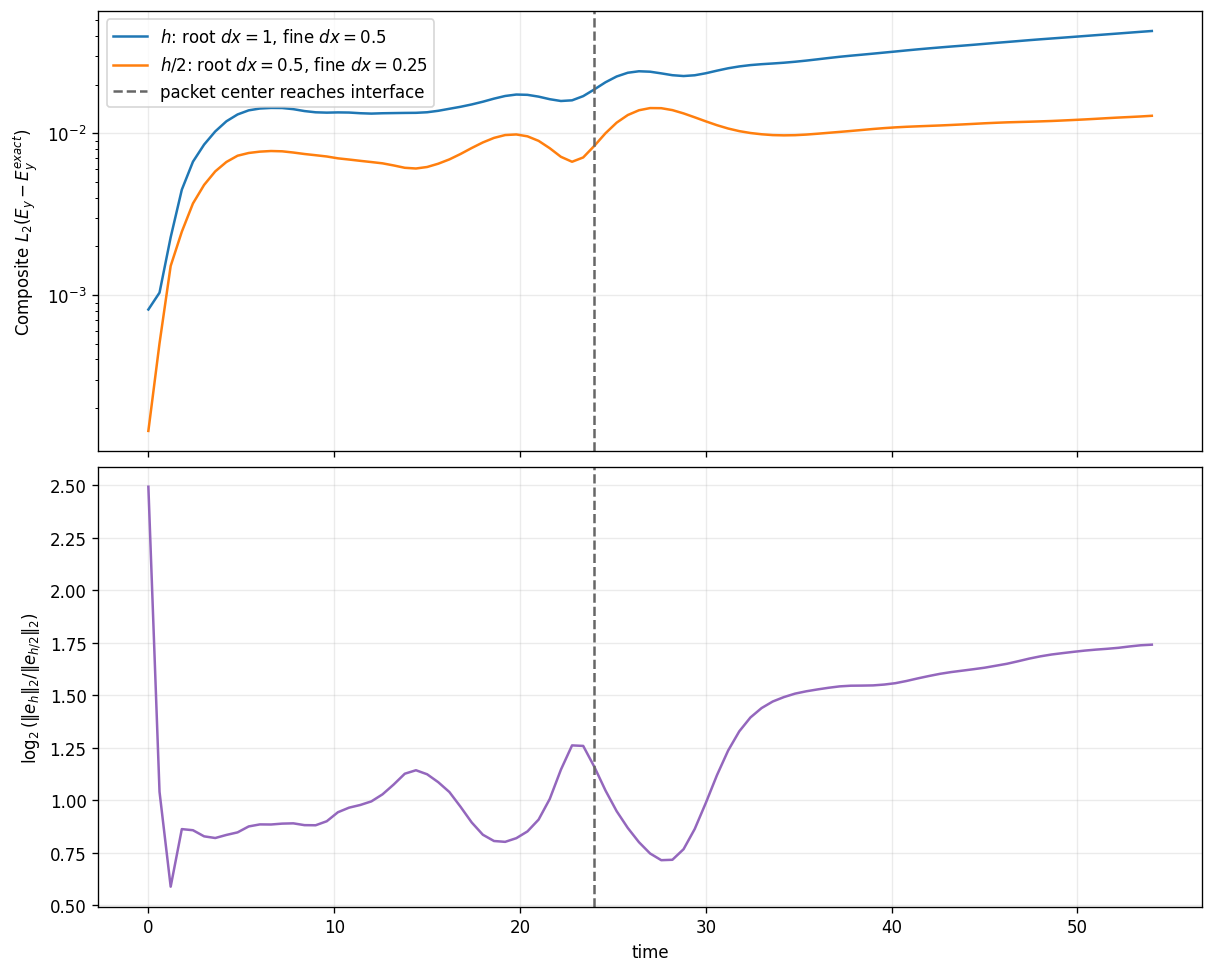

| Resolution | Root / fine dx | Final $L_2$ error | Peak $L_2$ error | Peak time |
|:---|:---:|---:|---:|---:|
| baseline $h$ | 1.000 / 0.500 | 4.297024e-02 | 4.297024e-02 | 54.0 |
| doubled $h/2$ | 0.500 / 0.250 | 1.284874e-02 | 1.433995e-02 | 27.0 |

Final observed order: 1.741711
Median observed order over defined frames: 1.127076


In [7]:
valid_order = (coarse["l2_error"] > ROUND_OFF_THRESHOLD) & (fine["l2_error"] > ROUND_OFF_THRESHOLD)
convergence_order = np.full(NUM_FRAMES, np.nan)
convergence_order[valid_order] = np.log2(
    coarse["l2_error"][valid_order] / fine["l2_error"][valid_order]
)

assert np.allclose(
    convergence_order[valid_order],
    np.log2(coarse["l2_error"][valid_order] / fine["l2_error"][valid_order]),
)

fig, (error_ax, order_ax) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
error_ax.semilogy(FRAME_TIMES, coarse["l2_error"], label=r"$h$: root $dx=1$, fine $dx=0.5$")
error_ax.semilogy(FRAME_TIMES, fine["l2_error"], label=r"$h/2$: root $dx=0.5$, fine $dx=0.25$")
error_ax.axvline(PATCH_MAX[0] - PULSE_CENTER, color="0.4", linestyle="--", label="packet center reaches interface")
error_ax.set_ylabel(r"Composite $L_2(E_y-E_y^{exact})$")
error_ax.grid(alpha=0.25)
error_ax.legend()

order_ax.plot(FRAME_TIMES, convergence_order, color="tab:purple")
order_ax.axvline(PATCH_MAX[0] - PULSE_CENTER, color="0.4", linestyle="--")
order_ax.set_xlabel("time")
order_ax.set_ylabel(r"$\log_2(\|e_h\|_2/\|e_{h/2}\|_2)$")
order_ax.grid(alpha=0.25)
plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
display(Image(data=plot_buffer.getvalue()))

summary_table = [
    "| Resolution | Root / fine dx | Final $L_2$ error | Peak $L_2$ error | Peak time |",
    "|:---|:---:|---:|---:|---:|",
]
for label, result in (("baseline $h$", coarse), ("doubled $h/2$", fine)):
    peak_index = int(np.argmax(result["l2_error"]))
    summary_table.append(
        f"| {label} | {result['root_spacing'][0]:.3f} / {result['fine_spacing'][0]:.3f} | "
        f"{result['l2_error'][-1]:.6e} | {result['l2_error'][peak_index]:.6e} | "
        f"{FRAME_TIMES[peak_index]:.1f} |"
    )
display(Markdown("\n".join(summary_table)))

finite_orders = convergence_order[np.isfinite(convergence_order)]
print(f"Final observed order: {convergence_order[-1]:.6f}")
print(f"Median observed order over defined frames: {np.median(finite_orders):.6f}")

## Inline side-by-side movie of numerical noise

Both panels show the composite $E_y-E_y^{exact}$ plane at $z=3$: root error outside the patch and native fine error inside it. The physical axes, frame times, and symmetric color scale are shared, so reflected noise can be compared directly.

In [8]:
def plane_data(result):
    root_x, root_y, root_z = result["root_axes"]
    fine_x, fine_y, fine_z = result["fine_axes"]
    root_z_index = int(np.argmin(np.abs(root_z - PLOT_Z)))
    fine_z_index = int(np.argmin(np.abs(fine_z - PLOT_Z)))
    root_plane = result["root_error"][:, :, :, root_z_index]
    fine_plane = result["fine_error"][:, :, :, fine_z_index]
    root_inside_patch = (
        (root_x[:, None] >= PATCH_MIN[0])
        & (root_x[:, None] < PATCH_MAX[0])
        & (root_y[None, :] >= PATCH_MIN[1])
        & (root_y[None, :] < PATCH_MAX[1])
    )
    visible_root_y = (root_y >= PATCH_MIN[1]) & (root_y < PATCH_MAX[1])
    visible_fine_y = (fine_y >= PATCH_MIN[1]) & (fine_y < PATCH_MAX[1])
    return {
        "root_x": root_x,
        "root_y": root_y,
        "fine_x": fine_x,
        "fine_y": fine_y,
        "root_plane": root_plane,
        "fine_plane": fine_plane,
        "root_inside_patch": root_inside_patch,
        "visible_root_y": visible_root_y,
        "visible_fine_y": visible_fine_y,
    }


movie_data = {scale: plane_data(result) for scale, result in results.items()}
ERROR_LIMIT = max(
    max(
        float(np.max(np.abs(data["root_plane"][:, :, data["visible_root_y"]]))),
        float(np.max(np.abs(data["fine_plane"][:, :, data["visible_fine_y"]]))),
    )
    for data in movie_data.values()
)
assert ERROR_LIMIT > 0.0

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True, constrained_layout=True)
meshes = []
titles = []
for ax, scale, panel_title in zip(
    axes,
    RESOLUTION_SCALES,
    ("Baseline: root dx=1, fine dx=0.5", "Doubled: root dx=0.5, fine dx=0.25"),
):
    data = movie_data[scale]
    masked_root = np.ma.masked_where(data["root_inside_patch"], data["root_plane"][0]).T
    root_mesh = ax.pcolormesh(
        data["root_x"], data["root_y"], masked_root,
        shading="nearest", cmap="RdBu_r", vmin=-ERROR_LIMIT, vmax=ERROR_LIMIT,
    )
    fine_mesh = ax.pcolormesh(
        data["fine_x"], data["fine_y"], data["fine_plane"][0].T,
        shading="nearest", cmap="RdBu_r", vmin=-ERROR_LIMIT, vmax=ERROR_LIMIT,
    )
    ax.add_patch(Rectangle(
        (PATCH_MIN[0], PATCH_MIN[1]),
        PATCH_MAX[0] - PATCH_MIN[0],
        PATCH_MAX[1] - PATCH_MIN[1],
        fill=False, edgecolor="black", linewidth=1.2, linestyle="--",
    ))
    title = ax.set_title(panel_title)
    ax.set_xlim(DOMAIN_MIN[0], DOMAIN_MAX[0])
    ax.set_ylim(PATCH_MIN[1], PATCH_MAX[1])
    ax.set_xlabel("x")
    meshes.append((root_mesh, fine_mesh))
    titles.append(title)

axes[0].set_ylabel("y")
colorbar = fig.colorbar(meshes[0][0], ax=axes, pad=0.02)
colorbar.set_label(r"$E_y-E_y^{exact}$")

def update_movie(frame_index):
    artists = []
    for scale, (root_mesh, fine_mesh), title in zip(RESOLUTION_SCALES, meshes, titles):
        data = movie_data[scale]
        masked_root = np.ma.masked_where(
            data["root_inside_patch"], data["root_plane"][frame_index]
        ).T
        root_mesh.set_array(masked_root.ravel())
        fine_mesh.set_array(data["fine_plane"][frame_index].T.ravel())
        title.set_text(
            ("Baseline: root dx=1, fine dx=0.5" if scale == 1 else "Doubled: root dx=0.5, fine dx=0.25")
            + f"\nt={FRAME_TIMES[frame_index]:.1f}"
        )
        artists.extend((root_mesh, fine_mesh, title))
    return artists

error_movie = FuncAnimation(
    fig, update_movie, frames=NUM_FRAMES, interval=50, blit=False
)
movie_html = error_movie.to_jshtml(default_mode="loop")
plt.close(fig)

assert NUM_FRAMES == len(FRAME_TIMES) == 91
assert "<script" in movie_html and "data:image" in movie_html
print(f"Shared error color range: [{-ERROR_LIMIT:.6e}, {ERROR_LIMIT:.6e}]")
display(HTML(movie_html))

Shared error color range: [-1.465605e+00, 1.465605e+00]


## Interpretation

The packet center reaches the fine-to-coarse interface near $t=24$. Compare the error movie and order history before, during, and after that crossing. A clean asymptotic regime should reduce the composite error under doubling; reflected or interface-localized structures can instead make the instantaneous log2 order vary strongly. Those variations are retained as diagnostic evidence rather than filtered or converted into a pass/fail gate.

## Total movie error

The movie already contains the signed field error $e(\mathbf{x},t)=E_y^{num}-E_y^{exact}$ at every frame. Its total error is the root-mean-square over the complete composite FMR volume and movie duration,

$$\mathcal{E}=\left[\frac{1}{T V}\int_0^T\int_{\Omega} e(\mathbf{x},t)^2\,dV\,dt\right]^{1/2}. $$

The spatial integral is exactly the composite norm used above: covered root cells are omitted and the native fine cells replace them. The temporal integral uses the trapezoidal rule over all 91 synchronized movie frames.

In [9]:
def spacetime_rms(l2_history):
    duration = FRAME_TIMES[-1] - FRAME_TIMES[0]
    return float(np.sqrt(np.trapezoid(l2_history**2, FRAME_TIMES) / duration))


movie_total_errors = {
    scale: spacetime_rms(result["l2_error"])
    for scale, result in results.items()
}
movie_total_order = np.log2(movie_total_errors[1] / movie_total_errors[2])

total_error_table = [
    "| Movie | Root / fine dx | Total RMS error |",
    "|:---|:---:|---:|",
]
for scale, label in ((1, "baseline $h$"), (2, "doubled $h/2$")):
    result = results[scale]
    total_error_table.append(
        f"| {label} | {result['root_spacing'][0]:.3f} / {result['fine_spacing'][0]:.3f} "
        f"| {movie_total_errors[scale]:.6e} |"
    )
display(Markdown("\n".join(total_error_table)))
print(f"Total-error order for the original coupled h-dt movie pair: {movie_total_order:.6f}")

| Movie | Root / fine dx | Total RMS error |
|:---|:---:|---:|
| baseline $h$ | 1.000 / 0.500 | 2.556031e-02 |
| doubled $h/2$ | 0.500 / 0.250 | 9.813788e-03 |

Total-error order for the original coupled h-dt movie pair: 1.381023


## Independent time and space convergence

The original pair halves $h$ and $\Delta t$ together, so it measures the complete discretization but does not isolate either truncation error. The following tests separate them while retaining the same wave, FMR patch, analytical subtraction, interface crossing, and total space-time norm.

- **Time:** hold the mesh fixed and use $\Delta t=(0.15,0.075,0.0375)$. The temporal error is isolated with differences of signed analytical-error movies, $e_{\Delta t}-e_{\Delta t/2}$. The analytical field cancels, as it must for a fixed-mesh time self-convergence test; this avoids mistaking the fixed spatial-error floor for time error.
- **Space:** refine the propagation direction by factors $(1,2,4)$ and hold $\Delta t/h_x$ fixed. The transverse mesh is unchanged because this solution is constant in $y,z$. Fine error movies are volume-averaged in adjacent x-cell pairs onto the next coarser native $E_y$ locations before differencing.

For either sequence, second order predicts a factor of four reduction and $p=\log_2(\mathcal{D}_{coarse}/\mathcal{D}_{fine})=2$.

In [10]:
def convergence_config(x_resolution_scale, dt, output_dir):
    config = fmr_config(1, output_dir)
    axis_scale = np.asarray((x_resolution_scale, 1, 1), dtype=int)
    root_shape = tuple(int(value) for value in axis_scale * BASE_ROOT_SHAPE)
    patch_start = tuple(int(value) for value in axis_scale * BASE_PATCH_START)
    patch_stop = tuple(int(value) for value in axis_scale * BASE_PATCH_STOP)

    config["static_parameters"].update({
        "name": f"2:1 FMR convergence, x-scale={x_resolution_scale}, dt={dt}",
        "Nt": int(round(FINAL_TIME / dt)),
        "particle_tile_nx": root_shape[0],
        "particle_tile_ny": root_shape[1],
        "particle_tile_nz": root_shape[2],
    })
    config["dynamic_parameters"].update({
        "Nx": root_shape[0],
        "Ny": root_shape[1],
        "Nz": root_shape[2],
        "dt": dt,
    })
    config["fmr"]["levels"][0].update({
        "coarse_start": list(patch_start),
        "coarse_stop": list(patch_stop),
    })
    return config


def run_convergence_case(x_resolution_scale, dt):
    with TemporaryDirectory(
        prefix=f"pypic3d_fmr_convergence_x{x_resolution_scale}_dt{dt}_"
    ) as output_dir:
        (
            evolve_loop,
            particles,
            fields,
            static_parameters,
            dynamic_parameters,
            _plotting_parameters,
            _plasma_parameters,
            species_config,
        ) = initialize_simulation(convergence_config(x_resolution_scale, dt, output_dir))
        fields = initialize_wave(fields, dynamic_parameters)

        steps_per_frame = int(round(FRAME_DT / dt))
        assert np.isclose(steps_per_frame * dt, FRAME_DT)

        root_level, fine_level = static_parameters.fmr_levels
        root_data, fine_data = dynamic_parameters.fmr.levels
        g = int(static_parameters.guard_cells)
        active_root = (
            slice(g, g + root_level.Nx),
            slice(g, g + root_level.Ny),
            slice(g, g + root_level.Nz),
        )
        active_fine = (
            slice(g, g + fine_level.Nx),
            slice(g, g + fine_level.Ny),
            slice(g, g + fine_level.Nz),
        )
        root_axes = tuple(
            active_component_axis(root_level, root_data, E_FIELD_LOCATIONS[1], axis, g)
            for axis in range(3)
        )
        fine_axes = tuple(
            active_component_axis(fine_level, fine_data, E_FIELD_LOCATIONS[1], axis, g)
            for axis in range(3)
        )

        def sample_Ey(field_state):
            E_levels = field_state[0]
            return (
                E_levels[0][1][0, 0, 0][active_root],
                E_levels[1][1][0, 0, 0][active_fine],
            )

        initial_Ey = sample_Ey(fields)

        def advance_one_step(field_state):
            _, field_state = evolve_loop(
                particles, species_config, field_state, static_parameters, dynamic_parameters
            )
            return field_state

        def advance_one_frame(field_state, _):
            field_state = jax.lax.fori_loop(
                0,
                steps_per_frame,
                lambda _step, state: advance_one_step(state),
                field_state,
            )
            return field_state, sample_Ey(field_state)

        @jax.jit
        def evolve_and_sample(field_state):
            return jax.lax.scan(
                advance_one_frame, field_state, xs=None, length=NUM_FRAMES - 1
            )

        _final_fields, histories = evolve_and_sample(fields)
        histories = tuple(
            jnp.concatenate((initial[jnp.newaxis], history), axis=0)
            for initial, history in zip(initial_Ey, histories)
        )
        histories[1].block_until_ready()

        root_Ey, fine_Ey = (
            np.asarray(jax.device_get(history)) for history in histories
        )
        root_axes = tuple(np.asarray(jax.device_get(axis)) for axis in root_axes)
        fine_axes = tuple(np.asarray(jax.device_get(axis)) for axis in fine_axes)
        root_error = root_Ey - analytic_history(root_axes[0])
        fine_error = fine_Ey - analytic_history(fine_axes[0])
        fine_spacing = np.asarray(fine_level.spacing, dtype=float)
        l2_error = composite_l2_history(
            root_error, fine_error, root_axes, fine_spacing
        )

        return {
            "x_resolution_scale": x_resolution_scale,
            "dt": dt,
            "root_spacing": np.asarray(root_level.spacing, dtype=float),
            "fine_spacing": fine_spacing,
            "root_axes": root_axes,
            "fine_axes": fine_axes,
            "root_error": root_error,
            "fine_error": fine_error,
            "l2_error": l2_error,
        }


def restrict_x_cell_average(error):
    assert error.shape[1] % 2 == 0
    return 0.5 * (error[:, 0::2] + error[:, 1::2])


def error_movie_difference(first, second, restrict_second=False):
    if restrict_second:
        second_root_error = restrict_x_cell_average(second["root_error"])
        second_fine_error = restrict_x_cell_average(second["fine_error"])
    else:
        second_root_error = second["root_error"]
        second_fine_error = second["fine_error"]

    root_difference = first["root_error"] - second_root_error
    fine_difference = first["fine_error"] - second_fine_error
    return composite_l2_history(
        root_difference, fine_difference, first["root_axes"], first["fine_spacing"]
    )

Running convergence case x-scale=1, dt=0.075...
Initializing Simulation: 2:1 FMR convergence, x-scale=1, dt=0.075

Using boundary conditions: x: periodic, y: periodic, z: periodic

Using user defined dt: 0.075
Adjusting t_wind to 54.0 based on provided dt and Nt

time window: 54.0 s with 720 time steps of 0.075 s
x window: 128.0 m [0.0, 128.0] with dx: 1.0 m
y window: 6.0 m [-1.1102230246251565e-16, 6.0] with dy: 1.0 m
z window: 6.0 m [-1.1102230246251565e-16, 6.0] with dz: 1.0 m

Skipping single-resolution energy diagnostics for field-only FMR

Relativistic simulation
Using boris particle pusher
Using field-only electrodynamic Yee FMR solver
Using J from rhov current calculation method with filter: none
Using tiled Yee storage with tile shape: (128, 6, 6)
Running convergence case x-scale=1, dt=0.0375...
Initializing Simulation: 2:1 FMR convergence, x-scale=1, dt=0.0375

Using boundary conditions: x: periodic, y: periodic, z: periodic

Using user defined dt: 0.0375
Adjusting t_wind to 

| Test | Coarse difference | Fine difference | Reduction | Observed order |
|:---|---:|---:|---:|---:|
| Time | 5.572957e-04 | 1.505616e-04 | 3.7014 | 1.8881 |
| Space | 1.714933e-02 | 4.790275e-03 | 3.5800 | 1.8400 |

| Sequence | Coarse parameter | Total analytical error | Pairwise order |
|:---|---:|---:|---:|
| fixed-space time | $\Delta t=0.1500$ | 2.556031e-02 | — |
| fixed-space time | $\Delta t=0.0750$ | 2.593830e-02 | — |
| fixed-space time | $\Delta t=0.0375$ | 2.603293e-02 | — |
| fixed-CFL space | $h_x=1.0000$ | 2.556031e-02 | — |
| fixed-CFL space | $h_x=0.5000$ | 1.305347e-02 | 0.9695 |
| fixed-CFL space | $h_x=0.2500$ | 1.192283e-02 | 0.1307 |

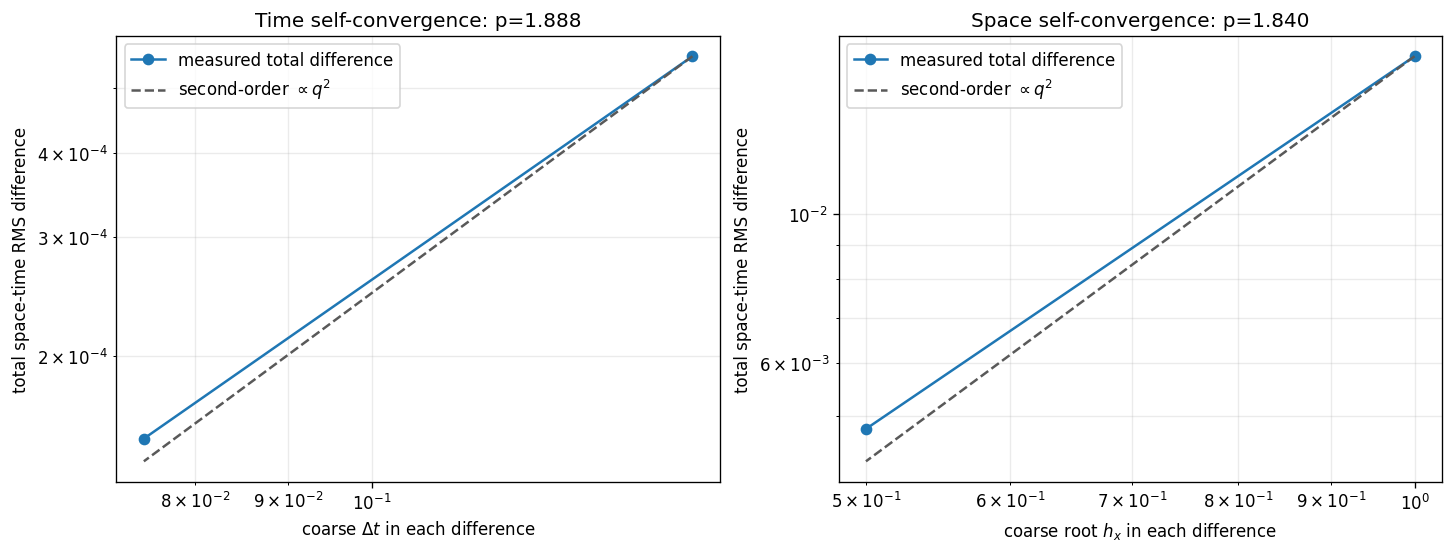

**Formal order:** time self-convergence gives $p_t=1.888$ and space self-convergence gives $p_x=1.840$; both lie in the second-order band $1.8 \le p \le 2.2$. However, the numerical-minus-analytical total error has spatial orders 0.969 and 0.131, so second-order convergence to the analytical crossing wave is **not** confirmed. The non-vanishing analytical-error floor is consistent with an FMR-interface error that mesh self-convergence alone cannot detect.

In [11]:
convergence_results = {(1, BASE_DT): coarse}
requested_cases = (
    (1, BASE_DT / 2),
    (1, BASE_DT / 4),
    (2, BASE_DT / 2),
    (4, BASE_DT / 4),
)
for x_resolution_scale, dt in requested_cases:
    print(f"Running convergence case x-scale={x_resolution_scale}, dt={dt}...")
    convergence_results[(x_resolution_scale, dt)] = run_convergence_case(
        x_resolution_scale, dt
    )

time_dt = convergence_results[(1, BASE_DT)]
time_dt_over_2 = convergence_results[(1, BASE_DT / 2)]
time_dt_over_4 = convergence_results[(1, BASE_DT / 4)]
time_difference_coarse = error_movie_difference(time_dt, time_dt_over_2)
time_difference_fine = error_movie_difference(time_dt_over_2, time_dt_over_4)
time_total_coarse = spacetime_rms(time_difference_coarse)
time_total_fine = spacetime_rms(time_difference_fine)
time_order = np.log2(time_total_coarse / time_total_fine)

space_h = convergence_results[(1, BASE_DT)]
space_h_over_2 = convergence_results[(2, BASE_DT / 2)]
space_h_over_4 = convergence_results[(4, BASE_DT / 4)]
space_difference_coarse = error_movie_difference(
    space_h, space_h_over_2, restrict_second=True
)
space_difference_fine = error_movie_difference(
    space_h_over_2, space_h_over_4, restrict_second=True
)
space_total_coarse = spacetime_rms(space_difference_coarse)
space_total_fine = spacetime_rms(space_difference_fine)
space_order = np.log2(space_total_coarse / space_total_fine)

time_analytic_totals = np.asarray([
    spacetime_rms(result["l2_error"])
    for result in (time_dt, time_dt_over_2, time_dt_over_4)
])
space_analytic_totals = np.asarray([
    spacetime_rms(result["l2_error"])
    for result in (space_h, space_h_over_2, space_h_over_4)
])
space_analytic_orders = np.log2(
    space_analytic_totals[:-1] / space_analytic_totals[1:]
)

SECOND_ORDER_BAND = (1.8, 2.2)
assert SECOND_ORDER_BAND[0] <= time_order <= SECOND_ORDER_BAND[1]
assert SECOND_ORDER_BAND[0] <= space_order <= SECOND_ORDER_BAND[1]

convergence_table = [
    "| Test | Coarse difference | Fine difference | Reduction | Observed order |",
    "|:---|---:|---:|---:|---:|",
    f"| Time | {time_total_coarse:.6e} | {time_total_fine:.6e} "
    f"| {time_total_coarse / time_total_fine:.4f} | {time_order:.4f} |",
    f"| Space | {space_total_coarse:.6e} | {space_total_fine:.6e} "
    f"| {space_total_coarse / space_total_fine:.4f} | {space_order:.4f} |",
]
display(Markdown("\n".join(convergence_table)))

analytic_error_table = [
    "| Sequence | Coarse parameter | Total analytical error | Pairwise order |",
    "|:---|---:|---:|---:|",
]
for index, (dt, total_error) in enumerate(zip(
    (BASE_DT, BASE_DT / 2, BASE_DT / 4), time_analytic_totals
)):
    analytic_error_table.append(
        fr"| fixed-space time | $\Delta t={dt:.4f}$ | {total_error:.6e} | — |"
    )
for index, (result, total_error) in enumerate(zip(
    (space_h, space_h_over_2, space_h_over_4), space_analytic_totals
)):
    order_text = "—" if index == 0 else f"{space_analytic_orders[index - 1]:.4f}"
    analytic_error_table.append(
        f"| fixed-CFL space | $h_x={result['root_spacing'][0]:.4f}$ "
        f"| {total_error:.6e} | {order_text} |"
    )
display(Markdown("\n".join(analytic_error_table)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, widths, errors, title, axis_label in (
    (
        axes[0],
        np.asarray((BASE_DT, BASE_DT / 2)),
        np.asarray((time_total_coarse, time_total_fine)),
        f"Time self-convergence: p={time_order:.3f}",
        r"coarse $\Delta t$ in each difference",
    ),
    (
        axes[1],
        np.asarray((space_h['root_spacing'][0], space_h_over_2['root_spacing'][0])),
        np.asarray((space_total_coarse, space_total_fine)),
        f"Space self-convergence: p={space_order:.3f}",
        r"coarse root $h_x$ in each difference",
    ),
):
    reference = errors[0] * (widths / widths[0])**2
    ax.loglog(widths, errors, "o-", label="measured total difference")
    ax.loglog(widths, reference, "--", color="0.35", label=r"second-order $\propto q^2$")
    ax.set_xlabel(axis_label)
    ax.set_ylabel("total space-time RMS difference")
    ax.set_title(title)
    ax.grid(alpha=0.25, which="both")
    ax.legend()
plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
display(Image(data=plot_buffer.getvalue()))

display(Markdown(
    f"**Formal order:** time self-convergence gives $p_t={time_order:.3f}$ and "
    f"space self-convergence gives $p_x={space_order:.3f}$; both lie in the "
    fr"second-order band ${SECOND_ORDER_BAND[0]:.1f} \le p \le {SECOND_ORDER_BAND[1]:.1f}$. "
    f"However, the numerical-minus-analytical total error has spatial orders "
    f"{space_analytic_orders[0]:.3f} and {space_analytic_orders[1]:.3f}, so "
    f"second-order convergence to the analytical crossing wave is **not** confirmed. "
    f"The non-vanishing analytical-error floor is consistent with an FMR-interface "
    f"error that mesh self-convergence alone cannot detect."
))